## Device

In [1]:
shared_folder_Path = "/media/marina/01DB47DC6EBB7DC0/ThreeD/shared"[:-6]
path = '/media/marina/01DB47DC6EBB7DC0/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo/'
path_model= '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/2_stacked/'
import sys,os, glob, torch
import pickle
sys.path.insert(1,shared_folder_Path)
try:
    os.mkdir('')
except:
    pass

paths_train = glob.glob(path + "/train/*")
paths_test  = glob.glob(path + "/test/*")
paths_test_low = [p for p in paths_test if ('motion_5' in p)]
paths_test_mid = [p for p in paths_test if ('motion_15' in p)]
paths_test_hgh = [p for p in paths_test if ('motion_25' in p)]
len(paths_train), len(paths_test_low), len(paths_test_hgh),len(paths_test)

(3, 400, 400, 1200)

## Import

In [2]:
%load_ext autoreload
%autoreload 2

import torch
from torch.optim import lr_scheduler
from torch.autograd import Variable
import numpy as np
import random
from tqdm import tqdm
import nibabel as nib
from shared.plot import plot_2_Imgs, plot_3_Imgs, plot_4_Imgs, plot_Img
from torch.utils.data import Dataset, DataLoader
from shared.ssim import SSIM
ssim_calc = SSIM()
from torchvision import transforms
import torch.nn.functional as F
from scipy import ndimage


def get_n_params( model):
    pp=0
    for p in list(model.parameters()):
        nn=1
        for s in list(p.size()):
            nn = nn*s
        pp += nn

    return pp


# Deterministic for spectral norm
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
def init_seeds(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(0)
    # no change in alg
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
init_seeds(42)

## Data

In [3]:
from shared.helpful_fns import FFT,IFFT,norm_0_1,real_2_complex_shape


In [4]:
def preprocess(kspace, k_space_artifact,Main_Artifact_path,mask):

    # IFFT
    image_Complex = IFFT(kspace)
    image_artifact_Complex = IFFT(k_space_artifact)
    
    # Img
    image = image_Complex.abs()
    image_artifact = image_artifact_Complex.abs()
    
    # Norm img
    image = norm_0_1(image)
    image_artifact = norm_0_1(image_artifact)
    

    # View
    kspace = torch.view_as_real(kspace)
    kspace = torch.moveaxis(kspace,-1,0)
    k_space_artifact = torch.view_as_real(k_space_artifact)
    k_space_artifact = torch.moveaxis(k_space_artifact,-1,0)
    image_Complex = torch.view_as_real(image_Complex)
    image_Complex = torch.moveaxis(image_Complex,-1,0)
    image_artifact_Complex = torch.view_as_real(image_artifact_Complex)
    image_artifact_Complex = torch.moveaxis(image_artifact_Complex,-1,0)


    return  {"Arr":image[None,...],
             "Arr_Complex":image_Complex,
                "Art":image_artifact[None,...],
             "Art_Complex":image_artifact_Complex,
                "K_Arr":kspace,
                "K_Art":k_space_artifact,
                'path':Main_Artifact_path,
                'Mask':abs(mask)[None],
            }

class MRIDataset(Dataset):
    def __init__(self, imgs_paths):
        self.imgs_paths = imgs_paths
    def __len__(self):
        return len(self.imgs_paths)
    def __getitem__(self, index):

        Main_Artifact_path = self.imgs_paths[index]
        kspace,k_space_artifact,mask = torch.load(Main_Artifact_path, weights_only=False)
        return  preprocess(kspace,k_space_artifact,Main_Artifact_path, mask)

3 1200
/media/marina/01DB47DC6EBB7DC0/0_Data/conp-dataset/projects/calgary-campinas/CC359/Raw-data/Single-channel/IM_MoCo//test/e14258s3_P76800.7._slice_78_motion_25.pt
BLUR:  tensor([0.2126])


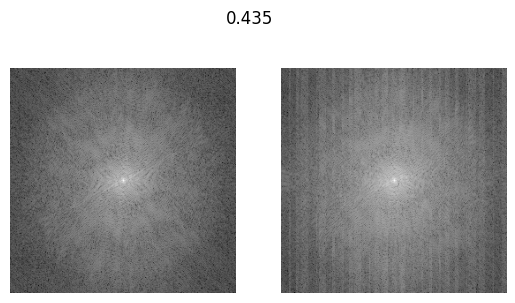

BLUR:  tensor([0.4792])


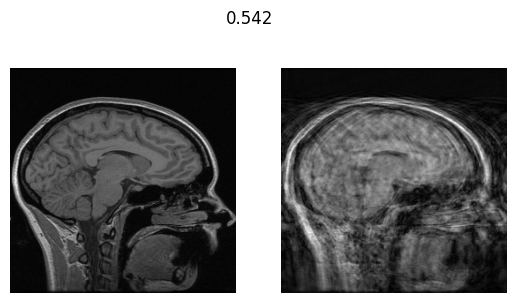

In [5]:
#dataset
dataset_train = MRIDataset(paths_train)
dataset_val = MRIDataset(paths_test)
print(len(dataset_train), len(dataset_val))

#dataloaders
batch_size = 1
dataloaders = dict()
dataloaders['train'] = DataLoader(dataset_train, batch_size=batch_size,
                                   shuffle=True, pin_memory=True)
dataloaders['val'] = DataLoader(dataset_val, batch_size=batch_size,
                                shuffle=False, pin_memory=True)
sample = dataset_val[random.randint(0,len(dataset_val))]

device = 'cpu'    
with torch.no_grad():
    print(sample['path'])
    Arr = sample['Arr'][None].to(device)
    Art = sample['Art'][None].to(device)
    
    K_Art = sample['K_Art'].to(device)
    K_Arr = sample['K_Arr'].to(device)
    K_Art = torch.view_as_complex(torch.moveaxis(K_Art,0,-1))
    K_Arr = torch.view_as_complex(torch.moveaxis(K_Arr,0,-1))
    
    plot_2_Imgs(K_Arr.abs().add(1e-9).log(),K_Art.abs().add(1e-9).log())
    plot_2_Imgs(Arr,Art)

## Model

31037057
-3
BLUR:  tensor([0.3019])


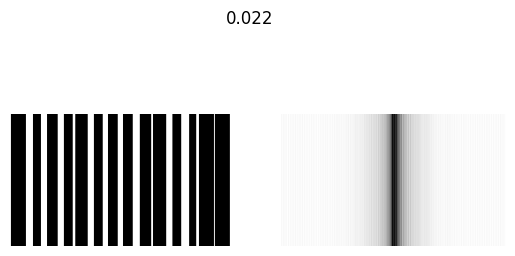

In [6]:
from motion_detection import *
model_motion_detection = UNet(2,1)#.cuda()
print(get_n_params(model_motion_detection))
p = -3#random.randint(0,len(dataset_val))
print(p)

sample= dataset_val[p]
device = 'cpu'
with torch.no_grad():

    mask = sample['Mask'][None].to(device)
    K_Art = sample['K_Art'][None].to(device)

    Mask_out,mask_pad,logits = model_motion_detection(K_Art,mask)    

    K_Art = real_2_complex_shape(K_Art)
    plot_2_Imgs(mask_pad,Mask_out)

In [7]:
from SWINUnet import *
model = SwinTransformerSys(img_size=256,num_classes=1,window_size=8,in_chans=1).cuda()
model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/5_PI_MoCo/29model.pt','cpu')
print(get_n_params(model))

/media/marina/01DB47DC6EBB7DC0/ThreeD/VENV_FASTMRI/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/media/marina/01DB47DC6EBB7DC0/ThreeD/VENV_FASTMRI/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.1;num_classes:3
64 64
32 32
16 16
16 16
32 32
64 64
---final upsample expand_first---
torch.Size([1, 3, 256, 256])
SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.1;num_classes:1
64 64
32 32
16 16
16 16
32 32
64 64
---final upsample expand_first---


/tmp/ipykernel_5112/61149970.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359

27172452


-1034


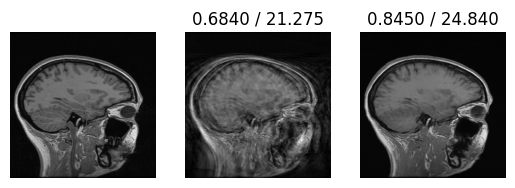

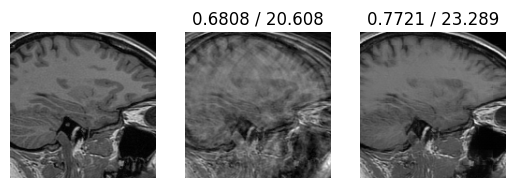

In [8]:
p = -1034#-600#random.randint(0,len(dataset_val))
print(p)
device = 'cpu'
sample= dataset_val[p]

with torch.no_grad():
    Img_arr = sample['Arr'][None].to(device)
    Art = sample['Art'][None].to(device)
    mask = sample['Mask'][None].to(device)
    
    Real_out = model(Art)    
    
    torch.save(Real_out,'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/PIMoCo_' + str(p) +'.pt')
    torch.save(Real_out[:,:,30:-63,30:-70],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Fig_Results/PIMoCo_sm_' + str(p) +'.pt')
    
    #plot_Img(Real_out)
    #plot_Img(Real_out[:,:,50:-50,50:-50])
    plot_3_Imgs(sample['Arr'][0],sample['Art'][0],Real_out[0,0])
    plot_3_Imgs(sample['Arr'][:,50:-50,50:-50],sample['Art'][:,50:-50,50:-50],Real_out[:,:,50:-50,50:-50])


## Outer

In [9]:
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)


input_img_3DNuFFT_sub8_run04 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run04.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = torch.view_as_complex(input_img_3DNuFFT_sub8_run04)
print(input_img_3DNuFFT_sub8_run04.shape)
input_img_3DNuFFT_sub8_run04 = F.pad( input_img_3DNuFFT_sub8_run04, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run04.shape)

input_img_3DNuFFT_sub8_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-08/input_img_3DNuFFT_run00.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub8_run00.shape)
#input_img_3DNuFFT_sub8_run00 = torch.view_as_complex(input_img_3DNuFFT_sub8_run00)
print(input_img_3DNuFFT_sub8_run00.shape)
input_img_3DNuFFT_sub8_run00 = F.pad( input_img_3DNuFFT_sub8_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub8_run00.shape)


input_img_3DNuFFT_sub1_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-00_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = torch.view_as_complex(input_img_3DNuFFT_sub1_run00)
print(input_img_3DNuFFT_sub1_run00.shape)
input_img_3DNuFFT_sub1_run00 = F.pad( input_img_3DNuFFT_sub1_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run00.shape)

input_img_3DNuFFT_sub1_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-01/sub-01_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = torch.view_as_complex(input_img_3DNuFFT_sub1_run01)
print(input_img_3DNuFFT_sub1_run01.shape)
input_img_3DNuFFT_sub1_run01 = F.pad( input_img_3DNuFFT_sub1_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub1_run01.shape)


input_img_3DNuFFT_sub2_run02 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-02_imgspace.pt','cpu',weights_only=False)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = torch.view_as_complex(input_img_3DNuFFT_sub2_run02)
print(input_img_3DNuFFT_sub2_run02.shape)
input_img_3DNuFFT_sub2_run02 = F.pad( input_img_3DNuFFT_sub2_run02, (0, 0,0,0, 17, 17), mode='constant', value=0)
print(input_img_3DNuFFT_sub2_run02.shape)


input_img_3DNuFFT_sub2_run01 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-01_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run01 = torch.view_as_complex(input_img_3DNuFFT_sub2_run01)
input_img_3DNuFFT_sub2_run01 = F.pad( input_img_3DNuFFT_sub2_run01, (0, 0,0,0, 17, 17), mode='constant', value=0)

input_img_3DNuFFT_sub2_run00 = torch.load('/media/marina/01DB47DC6EBB7DC0/0_Data/PMoCo3D/processedData/sub-02/sub-02_run-00_imgspace.pt','cpu',weights_only=False)
input_img_3DNuFFT_sub2_run00 = torch.view_as_complex(input_img_3DNuFFT_sub2_run00)
input_img_3DNuFFT_sub2_run00 = F.pad( input_img_3DNuFFT_sub2_run00, (0, 0,0,0, 17, 17), mode='constant', value=0)

torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])
torch.Size([222, 236, 256, 2])
torch.Size([222, 236, 256])
torch.Size([256, 236, 256])


105
torch.Size([256, 256])
tensor([0.4290])
BLUR: 0.429 aes:0.01125


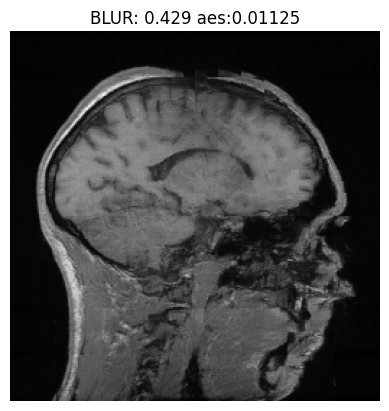

In [12]:
aa = input_img_3DNuFFT_sub2_run02
with torch.no_grad():
    t = 105#t+10
    print(t)

    Art = aa[:,t]
    print(Art.shape)
    Art = torch.tensor(ndimage.rotate(Art, -90))
    Art = abs(Art)[None][None]#.cuda()
    Art = norm_0_1(Art)

    with torch.no_grad():
        
        Real_out = model(Art) 
        #torch.save(Real_out[0,0,17:-17,:],'/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/PAPER_PLOTs/Cycle_REAL.pt')
        print(b(Real_out))
        #plot_2_Imgs(Art,Real_out) 
plot_Img(Real_out)

BLUR: 0.579 aes:0.00912


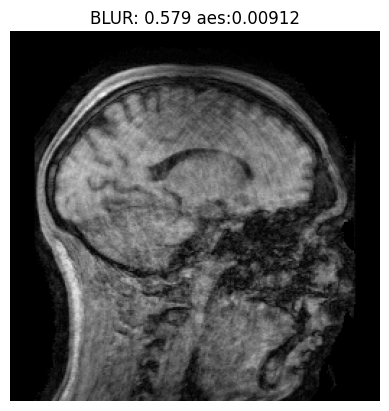

In [13]:
plot_Img(Art)     

## Loss & Optimization

In [ ]:
from shared.GradualWarmupSchedulerFile import *
from shared.ssim import SSIM
import torch.nn as nn
from shared.vgg_loss_folder import vgg_loss

learning_rate = 10**-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

SSIM_criterion = SSIM().to(device)
msee = nn.MSELoss().to(device)
L1Loss = nn.L1Loss().to(device)
crit_vgg = vgg_loss.VGGLoss().to(device)
BCE = nn.BCELoss().to(device)

def Dice(Mask_out, mask):
    Mask_out = (Mask_out > 0.5).float()
    a1 = torch.sum(Mask_out*mask)
    a2 = torch.sum(Mask_out)
    a3 = torch.sum(mask)
    num = 2*a1+10**6
    den = a2 + a3 + 10**-6
    return 1- (num / den)


/media/marina/01DB47DC6EBB7DC0/ThreeD/VENV_FASTMRI/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/marina/01DB47DC6EBB7DC0/ThreeD/VENV_FASTMRI/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Training

In [ ]:
def normLoss(x: torch.Tensor):
    if(x.shape[1]!=2):
        x = torch.concat((x.real,x.imag),1)
    b, c, h, w = x.shape
    x = x.view(b, 2, c // 2 * h * w)
  
    mean = x.mean(dim=2).view(b, 2, 1, 1)
    std = x.std(dim=2).view(b, 2, 1, 1)

    x = x.view(b, c, h, w)
    return (x - mean) / std#, mean, std

def complex_mse_loss(y_true, y_pred):
    y_true = normLoss(y_true)
    y_pred = normLoss(y_pred)
    y_true = y_true[:,0:1,:,:] + 1j * y_true[:,1:2,:,:]
    y_pred = y_pred[:,0:1,:,:] + 1j * y_pred[:,1:2,:,:]
    msee_real = msee(y_true.real,y_pred.real)
    msee_complex = msee(y_true.imag,y_pred.imag)
    
    return msee_real + msee_complex

In [ ]:
num_epochs = 50

for epoch in range( num_epochs):
    model.train()
    ssim_all = 0

    pbar_train = tqdm(enumerate(dataloaders['train']), total=len(dataloaders['train']), position=0, leave=True)
    for (i, data) in pbar_train:

        optimizer.zero_grad()

        mask = Variable(data['Mask']).to(device)
        K_Art = Variable(data['K_Art'].to(device))
        Art = Variable(data['Art'].to(device))
        Arr = Variable(data['Arr'].to(device))

        # Motion detection
        Mask_out_pad,Mask_Real_pad,logits = model_motion_detection(K_Art,mask)    
        loss_train1 = Dice(Mask_out_pad, Mask_Real_pad) +\
                      BCE(Mask_out_pad, Mask_Real_pad)

        logits_mean = logits.mean(dim=-2, keepdim=True)  # shape (batch, 1, 256, 1)
        logits_mean = logits_mean.expand_as(Art)    
        Mask_out = nn.Sigmoid()(logits_mean)


        # Motion correct
        Real_out = model(Art)
        
        Mo_L1 = L1Loss(Real_out, Arr)

        target_act = crit_vgg.get_features(Arr.repeat(1,3,1,1))
        Mo_L2 = crit_vgg((Real_out.repeat(1,3,1,1)),target_act, target_is_features=True)
        
        Mo_L3 = complex_mse_loss(  FFT(Arr)      * Mask_out,
                                   FFT(Real_out) * Mask_out)
        
        loss_train2 = 10*Mo_L1  + 0.5*Mo_L2 + 100*Mo_L3




        # Train        
        loss_train = loss_train1 + loss_train2
        loss_train.backward()
        optimizer.step()

















        ssim_all += SSIM_criterion(Real_out, Arr).cpu().detach()
        if(i%10==0):
            if((i==0) and (epoch==0)):
                file1 = open(path_model + "log.txt", "w")
            else:
                file1 = open(path_model + "log.txt", "a")
            file1.write("Epoch: " + str(epoch)+ "  , step: " + str(i) + "  , ssim_all: " + str(float(ssim_all/(i+1))) + "\n")
            file1.close()


    print("Train ssim_all " ,ssim_all/len(pbar_train))
    print( "epoch: " , epoch, 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")

    file1 = open(path_model + "log.txt", "a")
    file1.write("Epoch: " + str(epoch)+ "  , Train: " + "  , ssim_all: " + str(float(ssim_all/len(pbar_train))) + "\n"+ 'lr: '+ str(optimizer.param_groups[0]['lr'])+ "\n")
    file1.close()

    torch.save(model, path_model+"/"+str(epoch)+"model.pt")


    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    #~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~`
    with torch.no_grad():
      ssim_all = 0
      pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
      for (i, datatest) in pbar_test:

            Img_arr = Variable(datatest['Arr']).to(device)
            Art = Variable(datatest['Art']).to(device)
            
            real_correct = model(Art)
                
            ssim_all += SSIM_criterion(real_correct, Img_arr).cpu().detach()

      print("Test SSIM: " ,ssim_all/len(pbar_test))

      file1 = open(path_model + "log.txt", "a")
      file1.write("Epoch: " + str(epoch)+ "  , Test: " + "  , SSIM: " + str(float(ssim_all/len(pbar_test))) + "\n")
      file1.close()

100%|██████████| 3/3 [00:03<00:00,  1.30s/it]


Train ssim_all  tensor(0.9188)
epoch:  0 lr: 0.0001



  3%|▎         | 37/1200 [00:01<00:56, 20.52it/s]


KeyboardInterrupt: 

In [ ]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)
from shared.mutualInfo import mutual_information
import time

In [ ]:
from torcheval.metrics import PeakSignalNoiseRatio
metric = PeakSignalNoiseRatio()
from shared.ssim import SSIM
SSIM_criterion = SSIM().cuda()
from shared.CreateRoffetBlur import CreteRoffetBlur
b  = CreteRoffetBlur(2)
times = []

with torch.no_grad():
  ssim_all = [] ; psnr_bef=[] ; ssim_all_bef = []
  psnr=[] ; BLUR = [] ; BLUR_BEF = []
  MI = [] ; MI_BEF = []   
  pbar_test = tqdm(enumerate(dataloaders['val']), total=len(dataloaders['val']), position=0, leave=True)
  for (i, datatest) in pbar_test:

        path_ = (datatest['path'])[0]
        Arr = Variable(datatest['Arr']).to(device)
        Art = Variable(datatest['Art']).to(device)
        
        a = time.time()
        outputs_test = model(Art)
        times.append(time.time()-a)

        ssim_all .append(  float(SSIM_criterion(outputs_test, Arr).cpu().detach()))
        ssim_all_bef .append( float(SSIM_criterion(Art, Arr).cpu().detach()))

        metric = PeakSignalNoiseRatio()
        metric.update(outputs_test, Arr)
        paft = float(metric.compute())
        psnr.append( paft)

        metric = PeakSignalNoiseRatio()
        metric.update(Art, Arr)
        pbef = float(metric.compute())
        psnr_bef.append( pbef)

        BLUR .append( torch.sum(b(outputs_test)).cpu().detach())
        BLUR_BEF  .append( torch.sum(b(Art)).cpu().detach())


        MI .append( mutual_information(Arr,outputs_test))
        MI_BEF .append( mutual_information(Arr,Art))

        # save
        p = '/media/marina/01DB47DC6EBB7DC0/ThreeD/IDEA_2/zFINAL_ImMoCoArtifact_CC359data/5_PI_MoCo/data/'
        if(i==0):do='w'
        else: do = 'a'
      
        with open(p+ 'ssim_all.txt', do) as f:
            f.write( str(float(SSIM_criterion(outputs_test, Arr).cpu().detach())) + "\n" )
        with open(p+ 'ssim_all_bef.txt', do) as f:
            f.write( str(float(SSIM_criterion(Art, Arr).cpu().detach())) + "\n" )

        with open(p+ 'psnr_all.txt', do) as f:
            f.write( str(paft) + "\n" )
        with open(p+ 'psnr_all_bef.txt', do) as f:
            f.write( str(pbef) + "\n" )

        with open(p+ 'blur_all.txt', do) as f:
            f.write( str(float(torch.sum(b(outputs_test)).cpu().detach()))  + "\n" )
        with open(p+ 'blur_all_bef.txt', do) as f:
            f.write( str(float(torch.sum(b(Art)).cpu().detach())) + "\n" )
        
        with open(p+ 'MI_all.txt', do) as f:
            f.write( str(float(mutual_information(Arr,outputs_test)))  + "\n" )
        with open(p+ 'MI_all_bef.txt', do) as f:
            f.write( str(float(mutual_information(Arr,Art))) + "\n" )
        
        with open(p+ 'path.txt', do) as f:
            f.write( path_ + "\n" )

100%|██████████| 1200/1200 [02:57<00:00,  6.77it/s]


In [ ]:
print("ssim aft std :",np.std(ssim_all), "ssim mean :",np.mean(ssim_all))
print("ssim bef std :",np.std(ssim_all_bef), "ssim mean :",np.mean(ssim_all_bef) ,"\n")

print("psnr aft std :",np.std(psnr), "psnr mean :",np.mean(psnr))
print("psnr bef std :",np.std(psnr_bef), "psnr mean :",np.mean(psnr_bef),"\n")

print("Blur aft std :",np.std(BLUR), "Blur mean :",np.mean(BLUR))
print("Blur bef std :",np.std(BLUR_BEF), "Blur mean :",np.mean(BLUR_BEF),"\n")

print("MI aft std :",np.std(MI), "MI mean :",np.mean(MI))
print("MI bef std :",np.std(MI_BEF), "MI mean :",np.mean(MI_BEF),"\n")

print("time std :",np.std(times), "MI mean :",np.mean(times),"\n")

ssim aft std : 0.06925526402522632 ssim mean : 0.8737544096509615
ssim bef std : 0.12453755104871833 ssim mean : 0.7658770545820395 

psnr aft std : 3.508718261034541 psnr mean : 28.720095359484354
psnr bef std : 5.026714467870823 psnr mean : 25.071650342941282 

Blur aft std : 0.025332015 Blur mean : 0.41849294
Blur bef std : 0.021324178 Blur mean : 0.44909087 

MI aft std : 0.19176851804113512 MI mean : 1.1338033480968837
MI bef std : 0.2738904738789271 MI mean : 1.003781371839761 

time std : 0.011936701377731928 MI mean : 0.03648187736670176 

